# <span style="color:Thistle">Agregaciones: Mínimo, máximo, media...</span>

#### <span style="color:beige">Sesión 4</span>

A menudo, cuando nos enfrentamos a una gran cantidad de datos, el primer paso es calcular estadísticas resumen de los datos en cuestión. <span style="color:Gold">Como hemos hecho en el informe trabajado en clase.</span>

Estos datos como la media y la desviación estándar, permiten resumir los valores "típicos" de un conjunto de datos, pero también podemos calcular otra información que también son útiles (la suma, el producto, la mediana, el mínimo y máximo, los cuantiles y un largo etcétera).

NumPy tiene funciones de agregación rápidas integradas para trabajar con arrays. <span style="color:Gold">Una agregación basicamente significa pasar de una lista a un valor concreto</span>.

---
## Sumando los valores de un array

Como ejemplo rápido, consideremos calcular la suma de todos los valores de un array. El propio Python puede hacer esto usando la función integrada `sum`:

In [1]:
import numpy as np

In [2]:
lista = np.random.random(100)
sum(lista)
print(sum(lista))

54.28951230193245


<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Qué hace np.random.random?
</div>

La sintaxis es bastante similar a la de la función `sum` nativa de Python, y el resultado es el mismo en el caso más sencillo:

In [3]:
np.sum(lista)

np.float64(54.28951230193245)

Sin embargo, como ejecuta la operación sobre <span style="color:Gold">un tipo de datos fijado a enteros</span>, la versión de NumPy de la operación se calcula mucho más rápido:

In [4]:
array_grande = np.random.rand(1000000)
%timeit sum(array_grande)
%timeit np.sum(array_grande)

73.5 ms ± 875 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
565 μs ± 40.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Sin embargo, ten cuidado: la función `sum` y la función `np.sum` no son idénticas.

En particular, sus argumentos opcionales tienen significados distintos, y `np.sum` es consciente de las múltiples dimensiones del array.

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Por qué es más rápido sumar en NumPy?
</div>

---
## Mínimo y máximo

De forma similar, Python tiene las funciones integradas `min` y `max`, utilizadas para encontrar el valor mínimo y máximo dentro de cualquier array:

In [5]:
min(array_grande), max(array_grande)

(np.float64(6.288611751337214e-07), np.float64(0.9999961298687312))

Las funciones correspondientes de NumPy tienen una sintaxis similar, y de nuevo operan mucho más rápido:

In [6]:
np.min(array_grande), np.max(array_grande)

(np.float64(6.288611751337214e-07), np.float64(0.9999961298687312))

In [7]:
%timeit min(array_grande)
%timeit np.min(array_grande)

45.1 ms ± 1.97 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
291 μs ± 23.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Para `min`, `max`, `sum` y varios otras agregaciones de NumPy, una sintaxis más corta es usar los métodos del propio objeto array:

In [8]:
print(array_grande.min(), array_grande.max(), array_grande.sum())

6.288611751337214e-07 0.9999961298687312 500336.5706362533


<span style="color:Gold">**Asegúrate de estar usando la versión de NumPy de estas funciones cuando operes con arrays**</span>

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Es mejor min(array_grande) o array_grande.min()?
</div>

### Agregaciones en multiples dimensiones

Un tipo común de operación de agregación es sumar a lo largo de una fila o columna. Supongamos que tienes algunos datos almacenados en un array bidimensional:

In [9]:
M = np.random.random((3, 4))
print(M)

[[0.96681778 0.98794375 0.596467   0.52822246]
 [0.84858952 0.3200539  0.99100061 0.16376172]
 [0.13951068 0.88875449 0.87606448 0.08221217]]


<div class="alert alert-block alert-success">
<b>Nota:</b> Recuerda que esto crea una matriz de 3x4.
</div>

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Son Filas x Columas? ¿O Columnas x Filas? 
</div>

Por defecto, cada función de agregación de NumPy devolverá la suma sobre todo el array:

In [10]:
M.sum()

np.float64(7.3893985496350325)

Las funciones de agregación aceptan un argumento adicional que especifica el *eje* a lo largo del cual se calcula la agregación. Por ejemplo, podemos encontrar el valor mínimo dentro de cada columna especificando `axis=0`:

In [11]:
M.min(axis=0)

array([0.13951068, 0.3200539 , 0.596467  , 0.08221217])

La función devuelve cuatro valores, correspondientes a las cuatro columnas de números.

Del mismo modo, podemos encontrar el valor máximo dentro de cada fila:

In [12]:
M.max(axis=1)

array([0.98794375, 0.99100061, 0.88875449])

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Axis 0 es fila o columna?
</div>

La forma en que se especifica el eje aquí puede resultar confusa para usuarios que vienen de otros lenguajes. La palabra clave `axis` especifica la <span style="color:Gold">*dimensión del array que será colapsada*</span>, en lugar de la dimensión que será devuelta. 

Por tanto, especificar `axis=0` significa que el primer eje será colapsado: para arrays bidimensionales, esto significa que los valores dentro de cada columna serán agregados.

### Otras funciones de agregación

NumPy proporciona muchas otras funciones de agregación, algunas que ya conocemos y otras que todavía no usaremos.

Adicionalmente, la mayoría de las agregaciones tienen un <span style="color:Gold">operación segura</span> cuando encuentran valores `NaN`. 

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Qué significa NaN? ¿Es la primera vez que lo ves?
</div>

Normalmente es <span style="color:Gold">calcular el resultado ignorando los valores faltantes</span>, que están marcados con el valor especial IEEE de punto flotante `NaN` (más adelante ya veremos como gestionar ls datos faltantes).

La siguiente tabla proporciona una lista de funciones de agregación útiles disponibles en NumPy:

| Nombre de la función | Versión segura con NaN | Descripción |
|---|---|---|
| `np.sum` | `np.nansum` | Calcula la suma de los elementos |
| `np.prod` | `np.nanprod` | Calcula el producto de los elementos |
| `np.mean` | `np.nanmean` | Calcula la media de los elementos |
| `np.std` | `np.nanstd` | Calcula la desviación estándar |
| `np.var` | `np.nanvar` | Calcula la varianza |
| `np.min` | `np.nanmin` | Encuentra el valor mínimo |
| `np.max` | `np.nanmax` | Encuentra el valor máximo |
| `np.argmin` | `np.nanargmin` | Encuentra el índice del valor mínimo |
| `np.argmax` | `np.nanargmax` | Encuentra el índice del valor máximo |
| `np.median` | `np.nanmedian` | Calcula la mediana de los elementos |
| `np.percentile` | `np.nanpercentile` | Calcula estadísticas de rango de los elementos |
| `np.any` | N/D | Evalúa si algún elemento es verdadero |
| `np.all` | N/D | Evalúa si todos los elementos son verdaderos |

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Cuáles hemos visto hasta ahora en análisis de datos?
</div>

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Qué hacen argmin y argmax?
</div>

<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Qué hacen np.any y np.all?
</div>

---
## Ejemplo: ¿Cuál es la estatura media de los presidentes de EE.UU.?

Las agregaciones disponibles en NumPy pueden ser extremadamente útiles para resumir un conjunto de valores. Como ejemplo sencillo, consideremos las estaturas de todos los presidentes de EE.UU. Estos datos están disponibles en el archivo *altura_presidentes.csv*, que es una simple lista separada por comas de etiquetas y valores:

![Comando gc](https://i.imgur.com/yCpYTEk.png)

<div class="alert alert-block alert-success">
<b>Nota:</b> Con gc .\altura_presidentes.csv -Head 4 vemos las primeras 4 líneas del CSV.
</div>

Usaremos el <span style="color:Gold">paquete Pandas</span> para leer el archivo y extraer esta información (ten en cuenta que las estaturas se miden en centímetros). De momento sólo lo usaremos para leer el CSV y más adelante, veremos que es el paquete Pandas en profundidad.

In [21]:
import pandas as pd
datos = pd.read_csv('altura_presidentes.csv')
estaturas = np.array(datos['altura(cm)'])
print(estaturas)

[189 170 189 163 183 171 185 168 173 183 173 173 175 178 183 193 178 173
 174 183 183 168 170 178 182 180 183 178 182 188 175 179 183 193 182 183
 177 185 188 188 182 185]


Ahora que tenemos este array de datos, podemos calcular datos estadísticos con mucha facilidad:

In [28]:
print("Estatura media:         ", estaturas.mean())
print("Desviación estándar:    ", estaturas.std())
print("Estatura mínima:        ", estaturas.min())
print("Estatura máxima:        ", estaturas.max())
# REVISAR estaturas.median()
print("Mediana:                ", np.median(estaturas))


Estatura media:          179.73809523809524
Desviación estándar:     6.931843442745892
Estatura mínima:         163
Estatura máxima:         193
Mediana:                 182.0


<div class="alert alert-block alert-info">
<b>Pregunta:</b> ¿Qué desviación estándar deberiamos calcular, muestral o poblacional?
</div>

Vemos que la estatura mediana de los presidentes de EE.UU. es de 182 cms.

Vamos a ver la representación visual de estos datos, usando Matplotlib.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn
seaborn.set() 

Text(0, 0.5, 'presidentes')

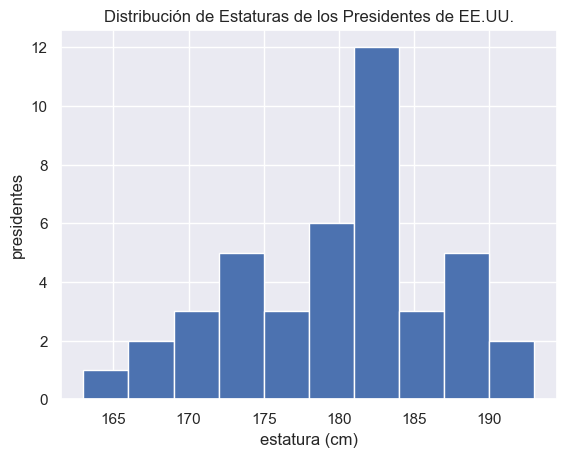

In [29]:
plt.hist(estaturas)
plt.title('Distribución de Estaturas de los Presidentes de EE.UU.')
plt.xlabel('estatura (cm)')
plt.ylabel('presidentes')

Estos agregaciones son algunas de las piezas fundamentales del <span style="color:Gold">análisis exploratorio de datos</span>.